In [3]:
from sentence_transformers import SentenceTransformer
import random 
import matplotlib.pyplot as plt

model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6033.62it/s]


In [4]:
sentences = [
    "I am a happy person.",
    "I am a joyful person.",
    "I am a pessimistic person.",
    "I am not an optimistic person."
]

embeddings = model.encode(sentences)

In [5]:
print(embeddings.shape)
print(embeddings[: , : 5])

(4, 384)
[[ 0.00464721  0.06651057  0.01479135 -0.02955692 -0.0355616 ]
 [ 0.0345459   0.05649187  0.00730666 -0.07299509 -0.06663916]
 [ 0.06152031  0.05317358  0.01788333  0.03482826 -0.03031247]
 [ 0.02471699  0.02527615 -0.00175564  0.02087234 -0.03713479]]


In [6]:
# Cosine similarity
similarity_matrix = model.similarity(embeddings , embeddings)
print(similarity_matrix)

tensor([[1.0000, 0.8151, 0.3864, 0.5210],
        [0.8151, 1.0000, 0.3383, 0.4128],
        [0.3864, 0.3383, 1.0000, 0.7047],
        [0.5210, 0.4128, 0.7047, 1.0000]])


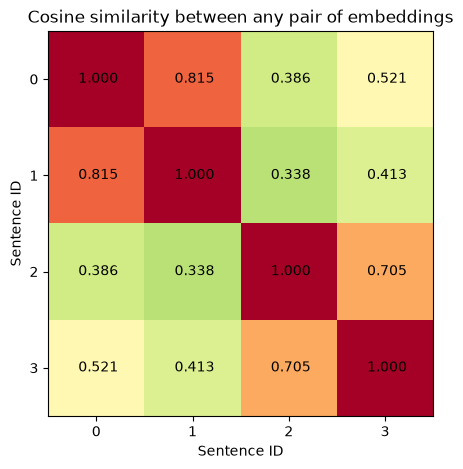

In [7]:
# Visualize the similarity matrix using heatmap 

plt.figure(figsize=(5,5))
plt.imshow(similarity_matrix,cmap="RdYlGn_r" , interpolation="nearest" , vmin=0 , vmax=1)
plt.title("Cosine similarity between any pair of embeddings")
plt.xlabel("Sentence ID")
plt.ylabel("Sentence ID")

plt.xticks([0,1,2,3])
plt.yticks([0,1,2,3])

for i in range(len(similarity_matrix)):
    for j in range(len(similarity_matrix)):
        plt.text(j,i,f'{similarity_matrix[i][j] : .3f}' , ha = "center" , va = "center" , color = "black")

plt.show()